# EBM-NLP Task 2: Preliminary Clustering Analysis

This notebook explores whether sentence embeddings form natural clusters that correspond to schema fields such as Participants, Interventions, and Outcomes.

In [1]:
## Importing the Liabraries  .....

import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import umap
import plotly.express as px

from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA

## Initial exploratory analysis using .txt files

In [2]:
folder_path = r"C:\Users\vikra\OneDrive\Desktop\Study_Board\Bristol\SEM 2\Introduction to AI and Text Analytics\AITA Coursework\EBM-NLP-master\ebm_nlp_1_00\documents"
all_sentences = []
doc_ids = []

max_files = 2000  # to avoid overloading  
file_count = 0

for file in os.listdir(folder_path):
    if file.endswith(".text"):   # correct extension
        file_path = os.path.join(folder_path, file)

        with open(file_path, encoding="utf-8", errors="ignore") as f:
            text = f.read().strip()

        # simple sentence segmentation
        sentences = re.split(r'(?<=[.!?])\s+', text)

        # removing extra spaces
        sentences = [s.strip() for s in sentences if s.strip()]

        all_sentences.extend(sentences)
        doc_ids.extend([file] * len(sentences))

        file_count += 1
        if file_count >= max_files:
            break

print("Files processed:", file_count)
print("Total sentences:", len(all_sentences))
print("Unique files:", len(set(doc_ids)))
print("\nSample sentences:")
for s in all_sentences[:5]:
    print("-", s)

Files processed: 2000
Total sentences: 22752
Unique files: 2000

Sample sentences:
- [Triple therapy regimens involving H2 blockaders for therapy of Helicobacter pylori infections].
- Comparison of ranitidine and lansoprazole in short-term low-dose triple therapy for Helicobacter pylori infection.
- To evaluate the efficacy and safety of two 1-week low-dose triple-therapy drug regimens involving antisecretory drugs for Helicobacter pylori infection, 99 patients with H.
- pylori infection were treated with either lansoprazole (LPZ) or ranitidine (RNT) used together with clarithromycin (CAM) and metrinidazole (MTZ).
- The drug combination and administration periods in the PPI group were LPZ 30 mg, CAM 400 mg, MTZ 500 mg (LCM group).


## Generating sentence Embeddings  ...

In [3]:
model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = model.encode(all_sentences, show_progress_bar=True)

print("Embeddings shape:", embeddings.shape)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/711 [00:00<?, ?it/s]

Embeddings shape: (22752, 384)


## Applying K-means Clustering algorithm ...

In [4]:
from sklearn.preprocessing import normalize
embeddings = normalize(embeddings)


kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(embeddings)

print("Total cluster labels:", len(cluster_labels))
print("Unique clusters:", np.unique(cluster_labels))

Total cluster labels: 22752
Unique clusters: [0 1 2]


In [5]:
df = pd.DataFrame({
    "sentence": all_sentences,
    "cluster": cluster_labels,
    "doc_id": doc_ids
})

df.sample(10, random_state=42)

,sentence,cluster,doc_id
16587,AIMS To assess if raising concentrations of cr...,2,17410213.text
16030,The data suggest that a 5 alpha-reductase gene...,2,1722167.text
1891,The result of this controlled clinical study c...,2,10763172.text
11550,Patients in the vitamin E group had a higher r...,2,15769967.text
9742,Combined information improved behavioral inten...,0,15193668.text
10346,Physician confidence in the treatment decision...,0,15358853.text
15929,BACKGROUND Psychosocial interventions can impr...,0,17179873.text
12643,No fever or severe gastrointestinal symptoms w...,2,16095766.text
3396,Nonparametric bootstrap sampling of costs/QALY...,0,11317090.text
12443,Mean followup was 5.96 years in the 2 groups.,0,16006861.text


## Inspecting sample sentences from each cluster

In [6]:
for i in range(3):
    print(f"\n===== Cluster {i} =====")
    sample_sentences = df[df["cluster"] == i]["sentence"].head(4)
    for s in sample_sentences:
        print("-", s)


===== Cluster 0 =====
- Patients of both the groups were evenly matched with respect to age, sex, body surface area, duration and severity of chronic obstructive pulmonary disease and coronary artery disease.
- Normal individuals who evenly matched with the study group were assessed for normal respiratory function parameters.
- Rhinocort Study Group.
- Secondarily to ascertain patients' preferences for the two nasal devices and to assess quality of life.

===== Cluster 1 =====
- Pre-operative short-term pulmonary rehabilitation for patients of chronic obstructive pulmonary disease undergoing coronary artery bypass graft surgery.
- The role of pre-operative short-term pulmonary rehabilitation in patients with chronic obstructive pulmonary disease who undergo coronary artery bypass graft surgery has been assessed for the first time prospectively.
- Forty-five patients posted for coronary artery bypass graft surgery were randomised to receive either short-term pulmonary rehabilitation (g

## PCA Visualization (for reference)

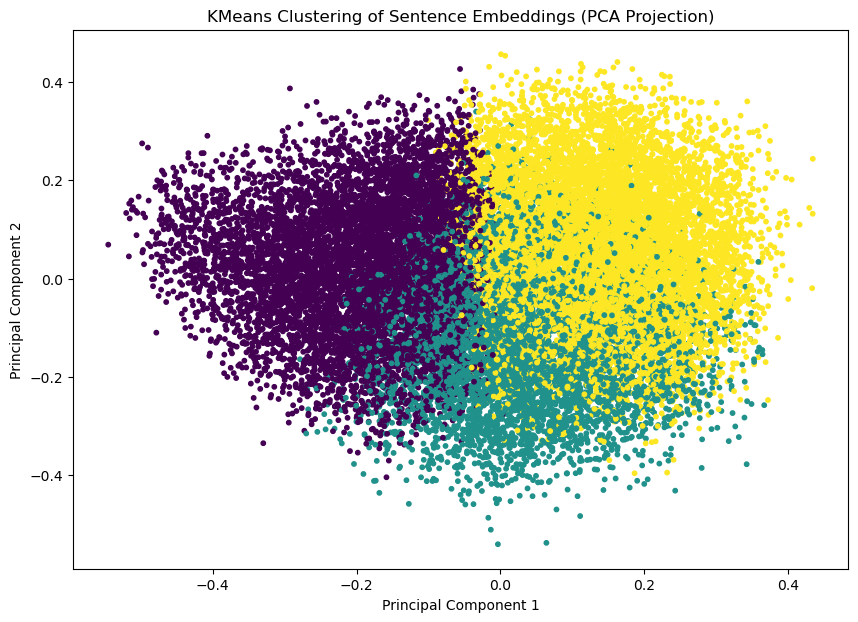

In [7]:
pca = PCA(n_components=2)
embeddings_2d_pca = pca.fit_transform(embeddings)

plt.figure(figsize=(10, 7))
plt.scatter(
    embeddings_2d_pca[:, 0],
    embeddings_2d_pca[:, 1],
    c=cluster_labels,
    s=10
)

plt.title("KMeans Clustering of Sentence Embeddings (PCA Projection)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

## UMAP Visualization on subset

C:\Users\vikra\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


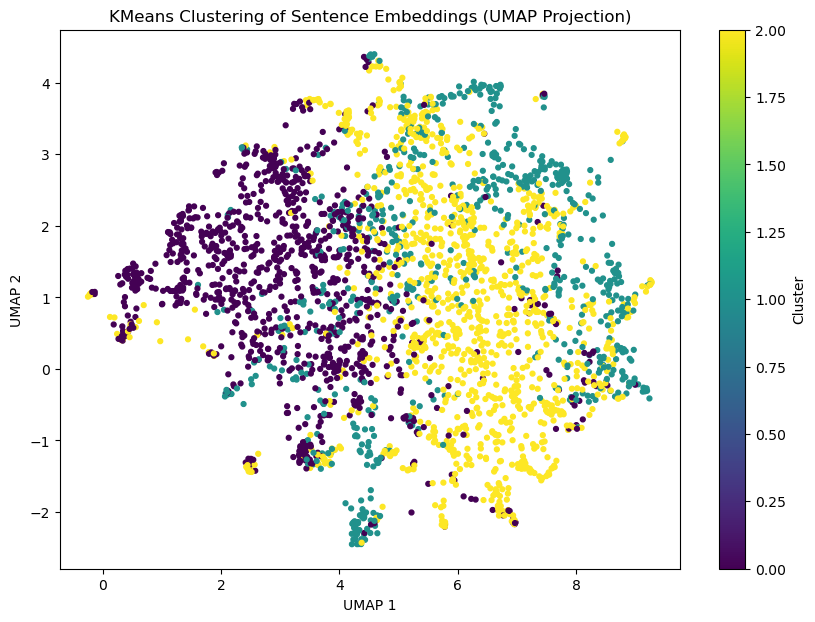

In [8]:
np.random.seed(42)
plot_idx = np.random.choice(len(embeddings), size=3000, replace=False)

embeddings_sample = embeddings[plot_idx]
cluster_sample = cluster_labels[plot_idx]

reducer = umap.UMAP(n_components=2, random_state=42)
embeddings_2d_umap = reducer.fit_transform(embeddings_sample)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    embeddings_2d_umap[:, 0],
    embeddings_2d_umap[:, 1],
    c=cluster_sample,
    s=12
)

plt.title("KMeans Clustering of Sentence Embeddings (UMAP Projection)")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.colorbar(scatter, label="Cluster")
plt.show()

## Applying Hierarchical Clustering on Subset ....

In [9]:
np.random.seed(42)
idx = np.random.choice(len(embeddings), size=2000)

embeddings_subset = embeddings[idx]
sentences_subset = [all_sentences[i] for i in idx]

hac = AgglomerativeClustering(n_clusters=3, linkage='ward')
hac_labels = hac.fit_predict(embeddings_subset)

C:\Users\vikra\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


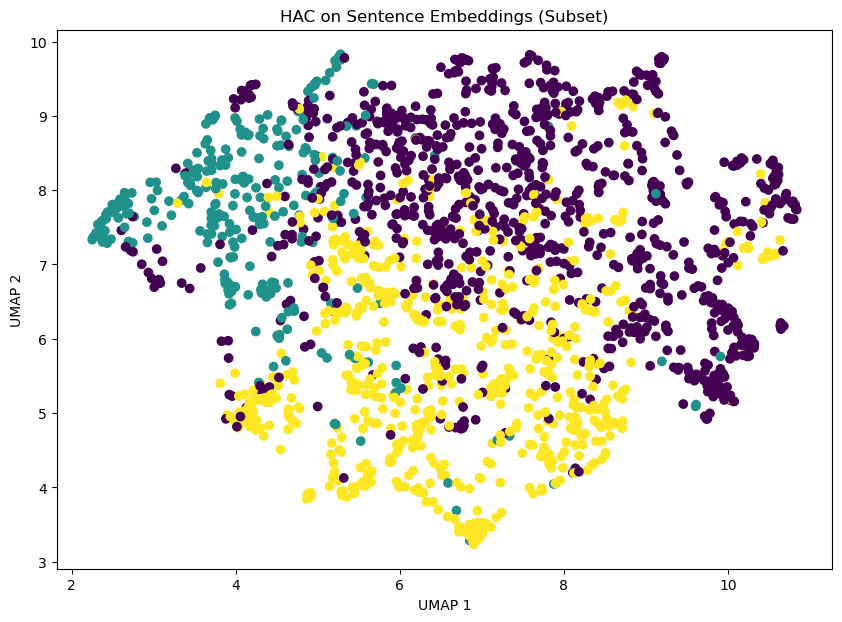

In [10]:
import umap
import matplotlib.pyplot as plt

reducer = umap.UMAP(n_components=2, random_state=20)
embeddings_subset_2d = reducer.fit_transform(embeddings_subset)

plt.figure(figsize=(10,7))
plt.scatter(embeddings_subset_2d[:,0], embeddings_subset_2d[:,1], c=hac_labels)
plt.title("HAC on Sentence Embeddings (Subset)")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.show()

## 3D umap visualization plot (for reference only)

C:\Users\vikra\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


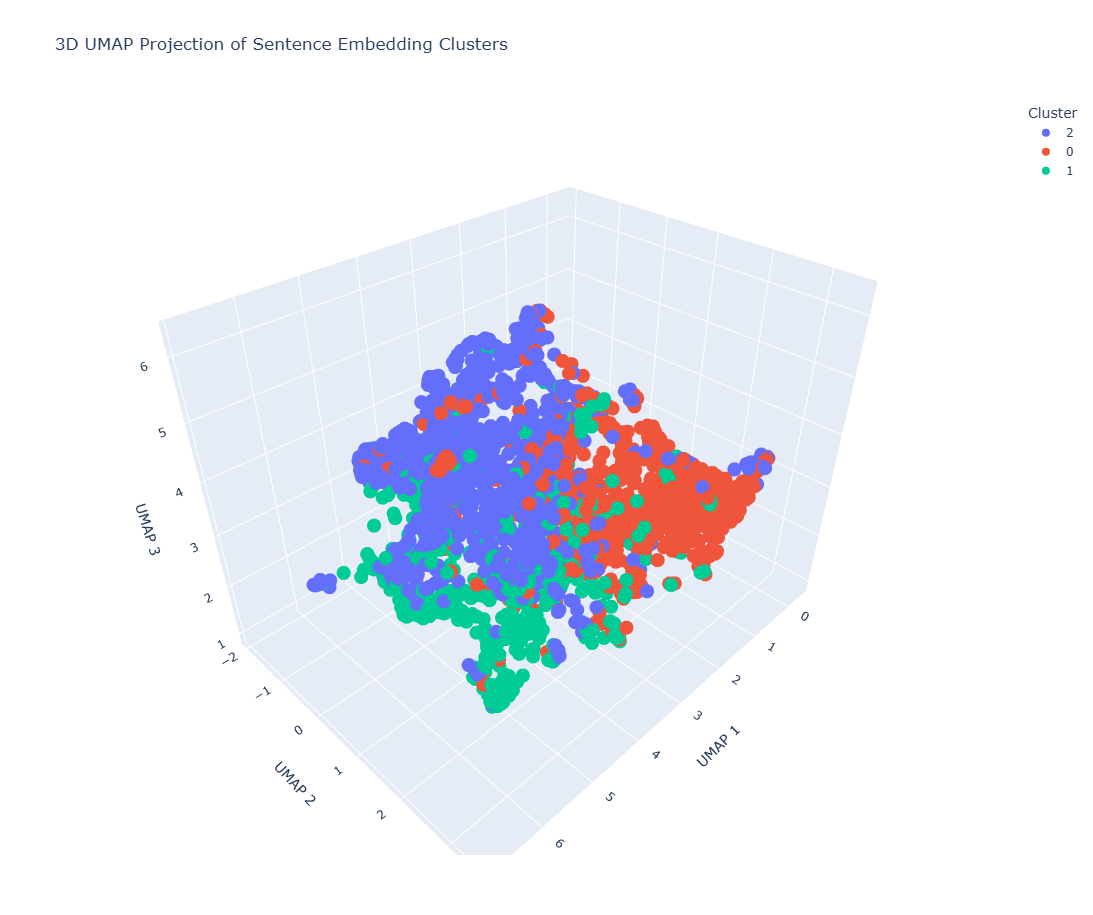

In [11]:
# random subset
np.random.seed(42)
plot_idx = np.random.choice(len(embeddings), size=3000, replace=False)

embeddings_sample = embeddings[plot_idx]
cluster_sample = cluster_labels[plot_idx]

# UMAP 3D
reducer_3d = umap.UMAP(n_components=3, random_state=42)
umap_result_3d = reducer_3d.fit_transform(embeddings_sample)

sample_sentences = [all_sentences[i] for i in plot_idx]

# create plot
fig = px.scatter_3d(
    x=umap_result_3d[:, 0],
    y=umap_result_3d[:, 1],
    z=umap_result_3d[:, 2],
    color=cluster_sample.astype(str),
    title="3D UMAP Projection of Sentence Embedding Clusters",
    labels={"color": "Cluster"},
    hover_data={"sentence": sample_sentences}
)

fig.update_layout(
    width=1200,
    height=900,
    margin=dict(l=60, r=60, b=60)
)

fig.update_layout(
    scene=dict(
        xaxis_title='UMAP 1',
        yaxis_title='UMAP 2',
        zaxis_title='UMAP 3'
    )
)

fig.show()

# =====================================
# Sentence Label Mapping (Using Annotations)
# =====================================

In [12]:
import os

base_path = r"C:\Users\vikra\OneDrive\Desktop\Study_Board\Bristol\SEM 2\Introduction to AI and Text Analytics\AITA Coursework\EBM-NLP-master\ebm_nlp_1_00"

documents_path = os.path.join(base_path, "documents")
ann_base = os.path.join(base_path, "annotations", "aggregated", "hierarchical_labels")

participants_path = os.path.join(ann_base, "participants", "train")
interventions_path = os.path.join(ann_base, "interventions", "train")
outcomes_path = os.path.join(ann_base, "outcomes", "train")

In [13]:
def read_text_file(file_path):
    with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
        return f.read().strip()

def read_tokens_file(file_path):
    with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
        return f.read().strip().split()

def read_labels_file(file_path):
    with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
        return f.read().strip().split(",")

In [14]:
pmid = "43164"

text_file = os.path.join(documents_path, f"{pmid}.text")
tokens_file = os.path.join(documents_path, f"{pmid}.tokens")

participants_file = os.path.join(participants_path, f"{pmid}_AGGREGATED.ann")
interventions_file = os.path.join(interventions_path, f"{pmid}_AGGREGATED.ann")
outcomes_file = os.path.join(outcomes_path, f"{pmid}_AGGREGATED.ann")

In [15]:
text = read_text_file(text_file)
tokens = read_tokens_file(tokens_file)

p_labels = read_labels_file(participants_file)
i_labels = read_labels_file(interventions_file)
o_labels = read_labels_file(outcomes_file)

# ---------- Debug ----------

print("Text length:", len(text))
print("Number of tokens:", len(tokens))
print("Participant labels:", len(p_labels))
print("Intervention labels:", len(i_labels))
print("Outcome labels:", len(o_labels))

Text length: 781
Number of tokens: 130
Participant labels: 130
Intervention labels: 130
Outcome labels: 130


In [16]:
print("First 20 tokens:")
print(tokens[:20])

print("\nFirst 20 participant labels:")
print(p_labels[:20])

print("\nFirst 20 intervention labels:")
print(i_labels[:20])

print("\nFirst 20 outcome labels:")
print(o_labels[:20])

First 20 tokens:
['A', 'double-blind', 'crossover', 'comparison', 'of', 'pindolol', ',', 'metoprolol', ',', 'atenolol', 'and', 'labetalol', 'in', 'mild', 'to', 'moderate', 'hypertension', '.', '1', 'This']

First 20 participant labels:
['0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0']

First 20 intervention labels:
['0', '0', '0', '0', '0', '3', '0', '3', '0', '3', '0', '3', '0', '0', '0', '0', '0', '0', '0', '0']

First 20 outcome labels:
['0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0']


In [17]:
def read_tokens_file(path):
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        text = f.read().strip()
    return text.split()

def read_label_file(path):
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        text = f.read().strip()
    return [int(x) for x in text.split(",") if x.strip() != ""]

In [18]:
pmid = "43164"

text_file = os.path.join(documents_path, f"{pmid}.text")
tokens_file = os.path.join(documents_path, f"{pmid}.tokens")

participants_file = os.path.join(participants_path, f"{pmid}_AGGREGATED.ann")
interventions_file = os.path.join(interventions_path, f"{pmid}_AGGREGATED.ann")
outcomes_file = os.path.join(outcomes_path, f"{pmid}_AGGREGATED.ann")

text = read_text_file(text_file)
tokens = read_tokens_file(tokens_file)
p_labels = read_label_file(participants_file)
i_labels = read_label_file(interventions_file)
o_labels = read_label_file(outcomes_file)

print("Text length:", len(text))
print("Number of tokens:", len(tokens))
print("Participant labels:", len(p_labels))
print("Intervention labels:", len(i_labels))
print("Outcome labels:", len(o_labels))

Text length: 781
Number of tokens: 130
Participant labels: 130
Intervention labels: 130
Outcome labels: 130


In [19]:
from collections import Counter

def tokens_to_sentence_labels(tokens, p_labels, i_labels, o_labels):
    sentences = []
    sentence_true_labels = []

    current_tokens = []
    current_labels = []

    for tok, p, i, o in zip(tokens, p_labels, i_labels, o_labels):
        current_tokens.append(tok)

        # collect schema hits
        if p > 0:
            current_labels.append("P")
        if i > 0:
            current_labels.append("I")
        if o > 0:
            current_labels.append("O")

        # sentence boundary
        if tok in [".", "!", "?"]:
            sentence_text = " ".join(current_tokens).strip()

            if len(current_labels) == 0:
                sentence_label = None
            else:
                counts = Counter(current_labels)
                sentence_label = counts.most_common(1)[0][0]

            sentences.append(sentence_text)
            sentence_true_labels.append(sentence_label)

            current_tokens = []
            current_labels = []

    # leftover tokens if any
    if current_tokens:
        sentence_text = " ".join(current_tokens).strip()

        if len(current_labels) == 0:
            sentence_label = None
        else:
            counts = Counter(current_labels)
            sentence_label = counts.most_common(1)[0][0]

        sentences.append(sentence_text)
        sentence_true_labels.append(sentence_label)

    return sentences, sentence_true_labels

In [20]:
sentences_all = []
true_labels_all = []
doc_ids_all = []

max_files = 1000
file_count = 0

for file in os.listdir(documents_path):
    if file.endswith(".tokens"):
        pmid = file.replace(".tokens", "")

        tokens_file = os.path.join(documents_path, f"{pmid}.tokens")
        participants_file = os.path.join(participants_path, f"{pmid}_AGGREGATED.ann")
        interventions_file = os.path.join(interventions_path, f"{pmid}_AGGREGATED.ann")
        outcomes_file = os.path.join(outcomes_path, f"{pmid}_AGGREGATED.ann")

        # skip if any annotation file missing
        if not (
            os.path.exists(participants_file)
            and os.path.exists(interventions_file)
            and os.path.exists(outcomes_file)
        ):
            continue

        tokens = read_tokens_file(tokens_file)
        p_labels = read_label_file(participants_file)
        i_labels = read_label_file(interventions_file)
        o_labels = read_label_file(outcomes_file)

        # ensure alignment
        if not (len(tokens) == len(p_labels) == len(i_labels) == len(o_labels)):
            continue

        file_sentences, file_true_labels = tokens_to_sentence_labels(
            tokens, p_labels, i_labels, o_labels
        )

        sentences_all.extend(file_sentences)
        true_labels_all.extend(file_true_labels)
        doc_ids_all.extend([pmid] * len(file_sentences))

        file_count += 1
        if file_count >= max_files:
            break

print("Files processed:", file_count)
print("Total sentences:", len(sentences_all))
print("Total true labels:", len(true_labels_all))
print("Total doc ids:", len(doc_ids_all))

Files processed: 1000
Total sentences: 11505
Total true labels: 11505
Total doc ids: 11505


In [21]:
filtered_sentences = []
filtered_true_labels = []
filtered_doc_ids = []

for s, lbl, doc_id in zip(sentences_all, true_labels_all, doc_ids_all):
    if lbl is not None:
        filtered_sentences.append(s)
        filtered_true_labels.append(lbl)
        filtered_doc_ids.append(doc_id)

print("Filtered sentences:", len(filtered_sentences))
print("Filtered true labels:", len(filtered_true_labels))

Filtered sentences: 8957
Filtered true labels: 8957


In [22]:
model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = model.encode(filtered_sentences, show_progress_bar=True)

print("Embeddings shape:", embeddings.shape)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/280 [00:00<?, ?it/s]

Embeddings shape: (8957, 384)


In [23]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(embeddings)

print("Total cluster labels:", len(cluster_labels))
print("Unique clusters:", np.unique(cluster_labels))

Total cluster labels: 8957
Unique clusters: [0 1 2]


In [24]:
df = pd.DataFrame({
    "sentence": filtered_sentences,
    "cluster": cluster_labels,
    "true_label": filtered_true_labels,
    "doc_id": filtered_doc_ids
})

df.head()

,sentence,cluster,true_label,doc_id
0,Pre-operative short-term pulmonary rehabilitat...,2,I,10052279
1,The role of pre-operative short-term pulmonary...,2,I,10052279
2,Forty-five patients posted for coronary artery...,2,I,10052279
3,Pre-operative and post-operative peak expirato...,2,O,10052279
4,Peak expiratory flow rate ( 220.0 +/- 12.9 and...,2,O,10052279


In [25]:
ct = pd.crosstab(df["cluster"], df["true_label"])
print(ct)

true_label     I     O    P
cluster                    
0            587   983  300
1           1597  1794  356
2            983  1952  405


In [25]:
ct.plot(kind="bar", stacked=True, figsize=(8, 5))
plt.title("Distribution of True Labels within Clusters")
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.show()

NameError: name 'ct' is not defined

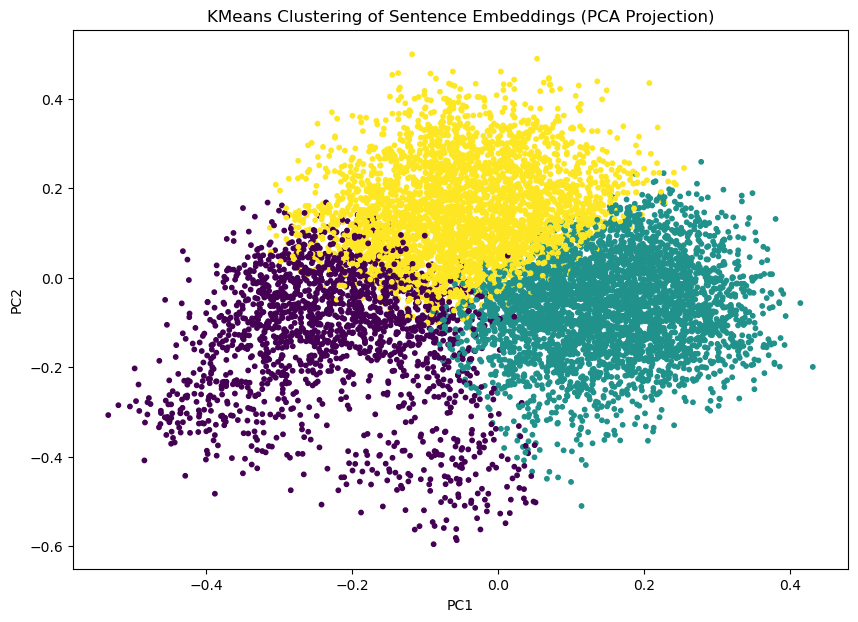

In [27]:
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings)

plt.figure(figsize=(10, 7))
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=cluster_labels, s=10)
plt.title("KMeans Clustering of Sentence Embeddings (PCA Projection)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

C:\Users\vikra\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



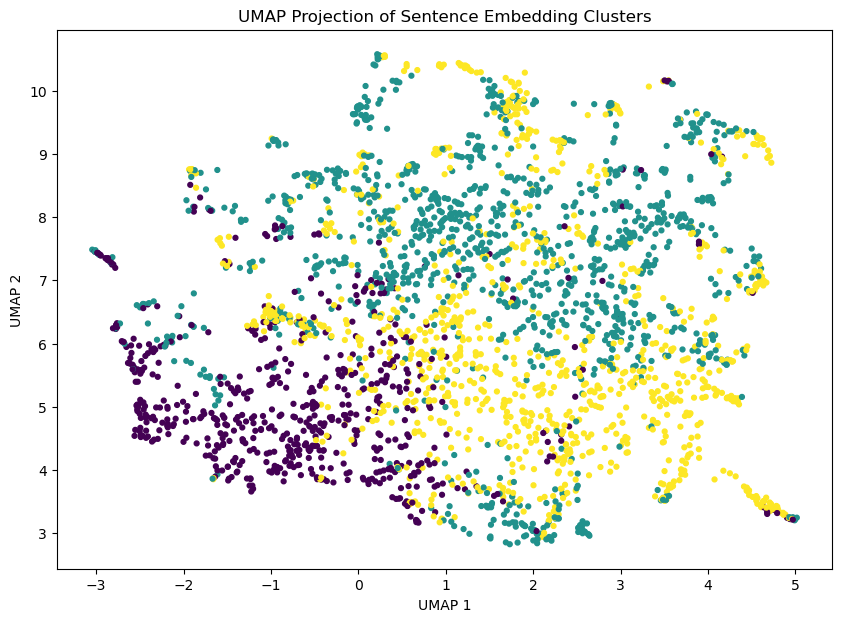

In [26]:
np.random.seed(42)
plot_idx = np.random.choice(len(embeddings), size=min(3000, len(embeddings)), replace=False)

embeddings_sample = embeddings[plot_idx]
cluster_sample = cluster_labels[plot_idx]

reducer = umap.UMAP(n_components=2, random_state=42)
embeddings_2d_umap = reducer.fit_transform(embeddings_sample)

plt.figure(figsize=(10, 7))
plt.scatter(embeddings_2d_umap[:, 0], embeddings_2d_umap[:, 1], c=cluster_sample, s=12)
plt.title("UMAP Projection of Sentence Embedding Clusters")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.show()

In [29]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

label_map = {"P": 0, "I": 1, "O": 2}
true_numeric = [label_map[x] for x in filtered_true_labels]

ari = adjusted_rand_score(true_numeric, cluster_labels)
nmi = normalized_mutual_info_score(true_numeric, cluster_labels)

print("ARI:", ari)
print("NMI:", nmi)

ARI: 0.012871116972950252
NMI: 0.00982019916747442
